# Global Retail Sales & Profitability Analysis

## Business Objective

The objective of this project is to analyze global retail sales performance, customer purchasing behavior, operational efficiency, and profitability across different markets. The analysis aims to identify the key drivers of revenue and profit, uncover operational inefficiencies, and provide data-driven recommendations that support strategic business decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

# Load the Dataset

In [2]:
df=pd.read_csv('superstore.csv')

# Data Understanding

In [3]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
df.shape

(51290, 27)

In [6]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [7]:
df['Order.Date']=pd.to_datetime(df['Order.Date'])
df['Ship.Date']=pd.to_datetime(df['Ship.Date'])

**The date columns were converted to datetime format to enable time-based calculations and shipping performance analysis.**

In [8]:
df['记录数'].value_counts()

记录数
1    51290
Name: count, dtype: int64

In [9]:
# Remove unnecessary column
df = df.drop(columns=['记录数'])

In [10]:
df['Shipping_Days']=df['Ship.Date']-df['Order.Date']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Category        51290 non-null  object         
 1   City            51290 non-null  object         
 2   Country         51290 non-null  object         
 3   Customer.ID     51290 non-null  object         
 4   Customer.Name   51290 non-null  object         
 5   Discount        51290 non-null  float64        
 6   Market          51290 non-null  object         
 7   Order.Date      51290 non-null  datetime64[ns] 
 8   Order.ID        51290 non-null  object         
 9   Order.Priority  51290 non-null  object         
 10  Product.ID      51290 non-null  object         
 11  Product.Name    51290 non-null  object         
 12  Profit          51290 non-null  float64        
 13  Quantity        51290 non-null  int64          
 14  Region          51290 non-null  object

# Data Cleaning Process

In [12]:
df.isnull().sum()

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
Shipping_Days     0
dtype: int64

**The dataset contains no missing values. Therefore, no imputation or removal of records was required, ensuring complete information for the analysis.**

In [13]:
df.duplicated().sum()

np.int64(0)

**No duplicate records were identified in the dataset. This indicates that each transaction is unique and no duplicate removal was necessary.**

## Data Cleaning
1. Checked for missing values
2. Checked duplicate records

# BUSINESS QUESTIONS

## Which countries generate the highest total sales?

In [14]:
# Calculate total sales by country
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
country_sales.head(10)

Country
United States     2297354
Australia          925257
France             858930
China              700591
Germany            628857
Mexico             622620
India              589664
United Kingdom     528570
Indonesia          404887
Brazil             361098
Name: Sales, dtype: int64

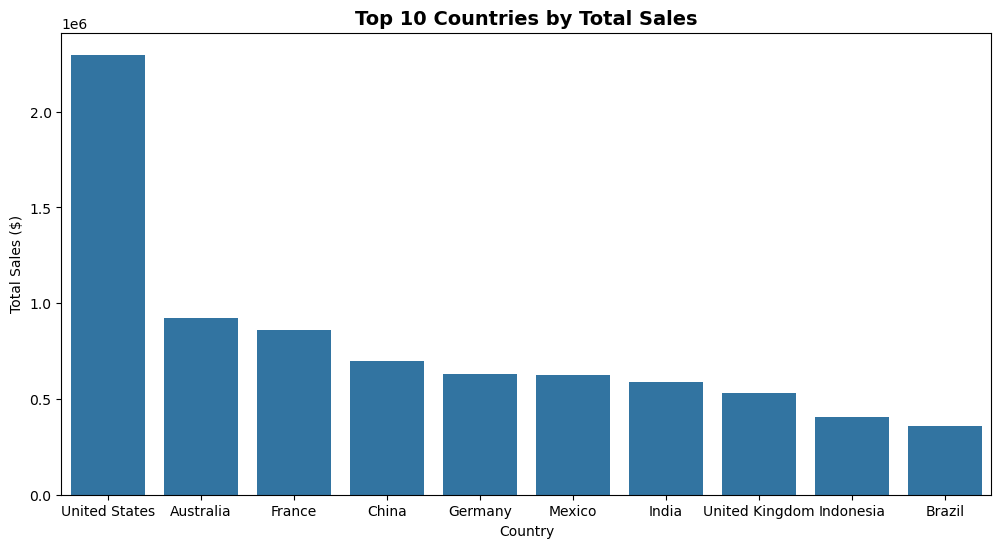

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x=country_sales.head(10).index,y=country_sales.head(10).values)
plt.title('Top 10 Countries by Total Sales',fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Total Sales ($)')
plt.show()

**1 — USA dominates massively
At ~$2.3M the US generates 2.4x more than Australia (second place) and nearly 6x more than Brazil (last). Similar pattern to what you saw with UK in the e-commerce dataset.**

**2 — Strong geographic diversity
Unlike the e-commerce dataset where UK dominated at 87%, here the top 10 covers 4 continents — Americas, Europe, Asia, Oceania. Much more balanced international spread.**

**3 — Interesting mix of developed and emerging markets
Mexico, India, Indonesia, Brazil appearing in top 10 suggests this is a global consumer product with mass market appeal.**

## Which markets generate the highest profit?

In [16]:
market_profit =df.groupby('Market')['Profit'].sum().sort_values(ascending=False)
market_profit

Market
APAC      436000.04900
EU        372829.74150
US        286397.02170
LATAM     221643.48708
Africa     88871.63100
EMEA       43897.97100
Canada     17817.39000
Name: Profit, dtype: float64

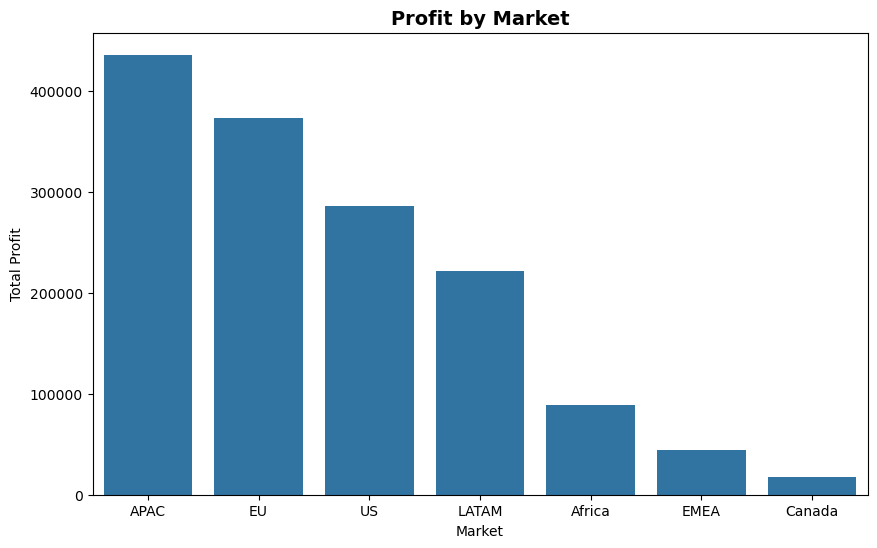

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=market_profit.index,y=market_profit.values)
plt.title('Profit by Market',fontsize=14, fontweight='bold')
plt.xlabel('Market')
plt.ylabel('Total Profit')
plt.show()

#### The big surprise — APAC leads in profit but US leads in sales!

Remember from the previous chart US had ~$2.3M in sales — by far the largest. But here APAC has the highest profit at ~$440,000 while US is only 3rd at ~$288,000.
This means:

**US   → huge sales volume but lower profit margins**

**APAC → lower sales volume but much higher profit margins**

#### This is a critical business insight — revenue ≠ profit.

## Which regions are underperforming?

In [18]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values()
region_profit

Region
Canada             17817.39000
Southeast Asia     17852.32900
Caribbean          34571.32104
EMEA               43897.97100
Africa             88871.63100
East               91522.78000
West              108418.44890
Oceania           120089.11200
Central Asia      132480.18700
South             140355.76618
North Asia        165578.42100
North             194597.95252
Central           311403.98164
Name: Profit, dtype: float64

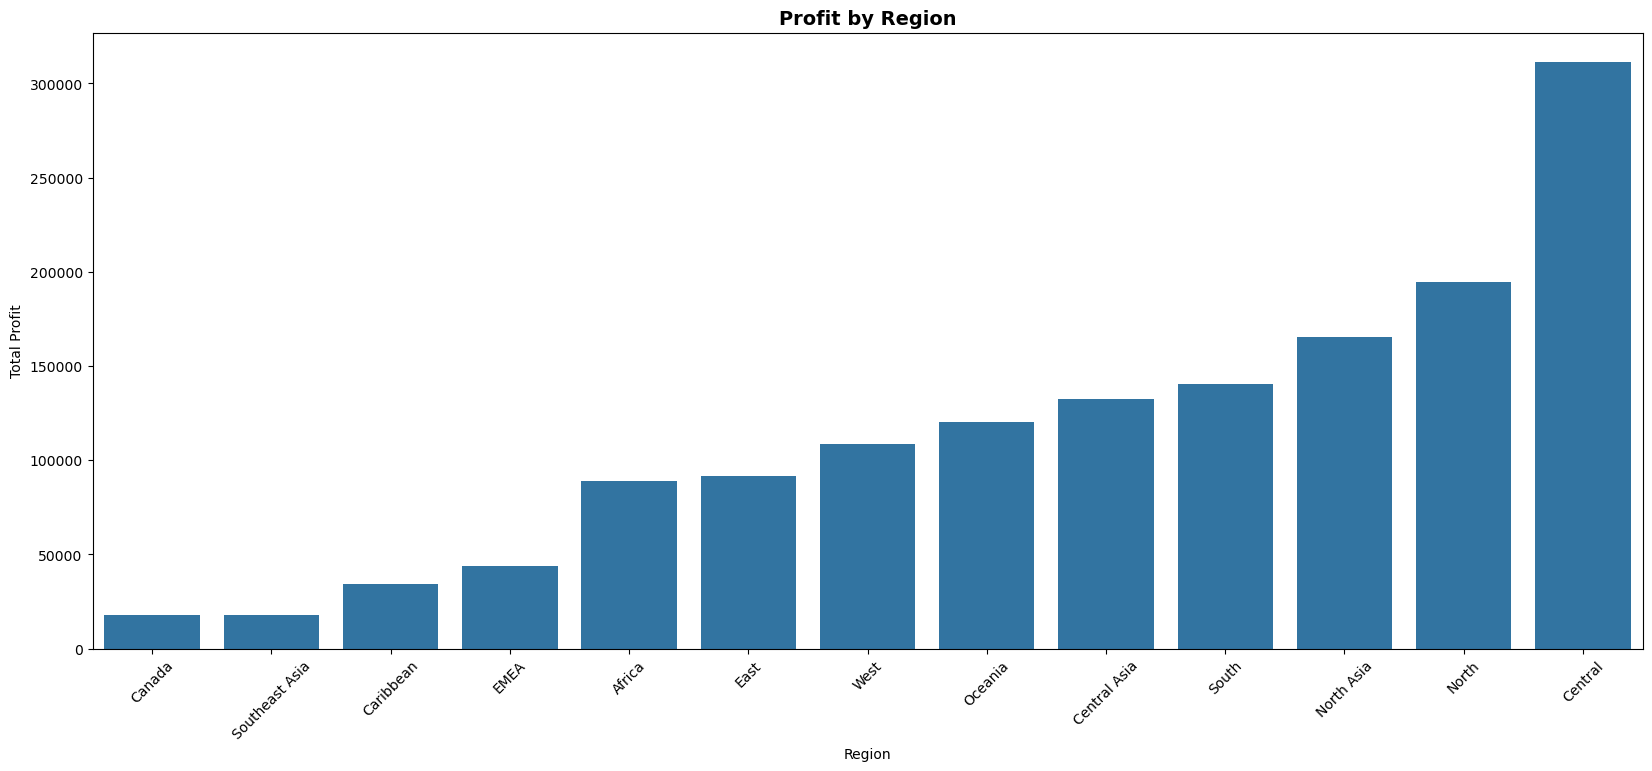

In [19]:
plt.figure(figsize=(20,8))
sns.barplot( x=region_profit.index, y=region_profit.values)
plt.title('Profit by Region',fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

**1 — Central dominates massively
~$315,000 — nearly double second place (North at ~$195,000). Central is by far the most profitable region.**

**2 — Canada and Southeast Asia are barely profitable
At ~$17–18K they are generating almost nothing. The company should investigate whether these markets are worth the operational cost.**

**3 — This connects to the previous chart
APAC being the most profitable market is confirmed here — North Asia, Central Asia, Oceania all appear in the top half.**

## How have total sales evolved over time?

In [20]:
yearly_sales =df.groupby('Year')['Sales'].sum()
yearly_sales

Year
2011    2259511
2012    2677493
2013    3405860
2014    4300041
Name: Sales, dtype: int64

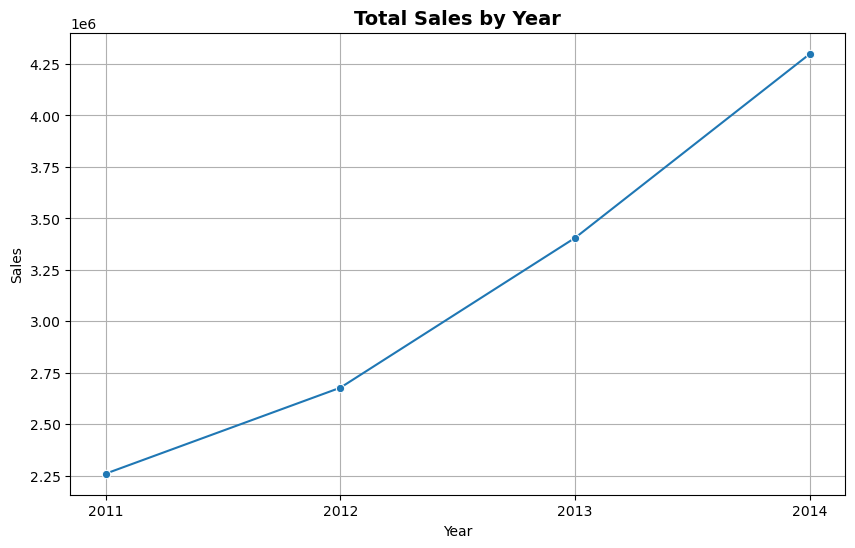

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_sales.index,y=yearly_sales.values,marker='o')
plt.title('Total Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.xticks([2011, 2012, 2013, 2014])
plt.show()

**1 — Perfectly consistent growth every year
Unlike the stock market or hotel datasets where you saw dips, this business grew every single year with no exceptions.**

**2 — Growth is accelerating
2011→2012: +$420K  (+18%)
2012→2013: +$725K  (+27%)
2013→2014: +$894K  (+26%)
The absolute growth is getting bigger each year — the business is compounding its growth.**

**3 — Sales nearly doubled in 3 years
From $2.26M to $4.3M — +90% total growth in just 3 years. This is a very healthy business trajectory.**

## Which cities generate the highest revenue?

In [22]:
city_sales =df.groupby('City')['Sales'].sum().sort_values(ascending=False)
city_sales.head(10)

City
New York City    256397
Los Angeles      175857
Manila           120896
Seattle          119552
San Francisco    112690
Philadelphia     109085
Sydney           101952
Jakarta           94318
London            86945
Mexico City       85732
Name: Sales, dtype: int64

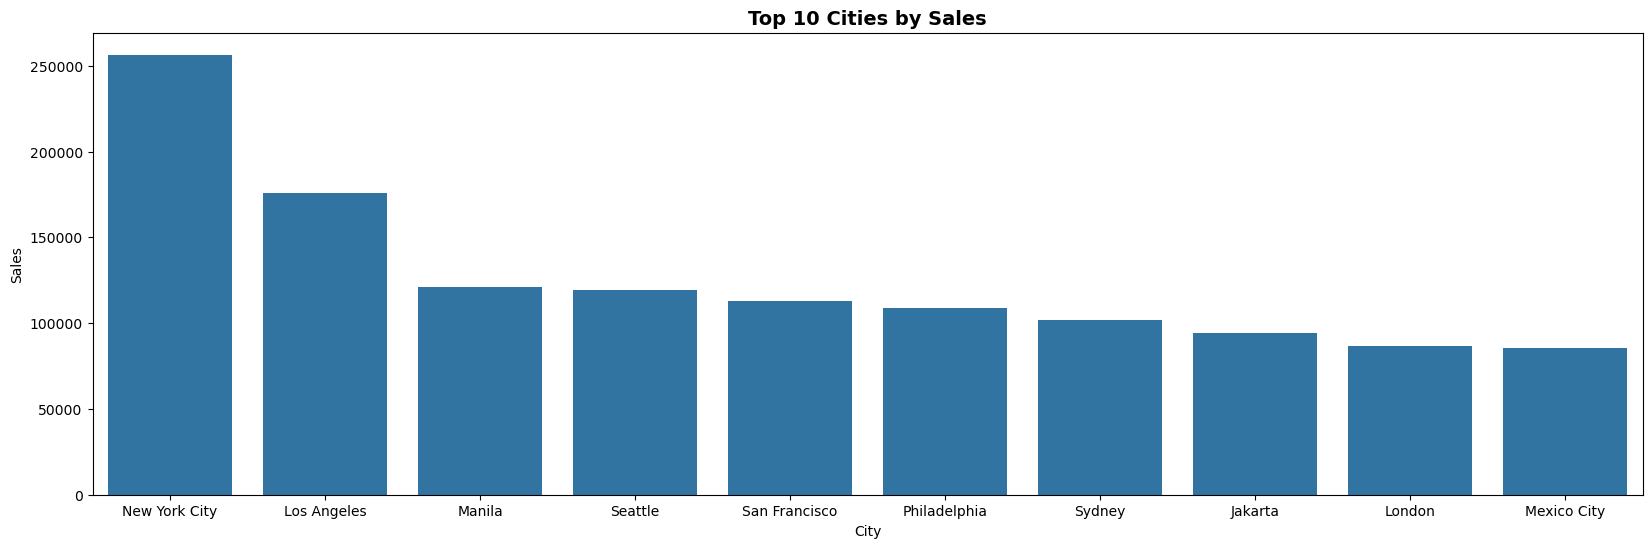

In [23]:
plt.figure(figsize=(20,6))
sns.barplot(x=city_sales.head(10).index,y=city_sales.head(10).values)
plt.title('Top 10 Cities by Sales', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Sales')
plt.show()

**1 — New York City dominates
At ~$258,000 it is 47% ahead of second place (Los Angeles at ~$175,000) — a very significant gap for a city-level comparison.**

**2 — US cities dominate the top
NYC, LA, Seattle, San Francisco, Philadelphia — 5 of the top 10 are US cities, consistent with the US being the #1 country by sales.**

**3 — Interesting international presence
Manila (#3), Sydney (#7), Jakarta (#8), London (#9), Mexico City (#10) — showing genuinely global reach across 5 different countries in the top 10.**

**4 — Manila is surprisingly high
The Philippines capital at #3 above all major European cities is unexpected — suggests a strong distribution or corporate presence there.**

## Which product categories generate the highest sales?

In [24]:
category_sales =df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: Sales, dtype: int64

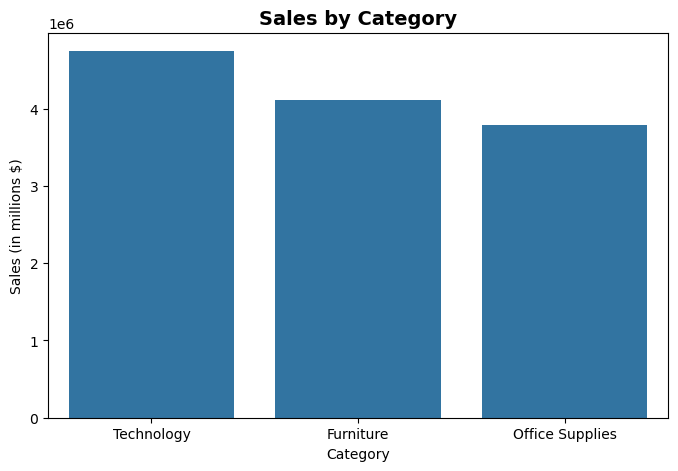

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index,y=category_sales.values)
plt.title('Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Sales (in millions $)')
plt.show()

**1 — Technology leads but all three are very close
Only a 22% difference between Technology (~$4.65M) and Office Supplies (~$3.82M) — much more balanced than most other charts in this analysis.**

**2 — This is the Global Superstore so numbers are much larger than the regular Superstore dataset**

**3 — Same ranking as before
Technology → Furniture → Office Supplies — exactly the same order as the US-only dataset. The global pattern mirrors the US pattern.**

## Which sub-categories generate the highest profit?

In [26]:
subcategory_profit =df.groupby('Sub.Category')['Profit'].sum().sort_values(ascending=False)
subcategory_profit

Sub.Category
Copiers        258567.54818
Phones         216717.00580
Bookcases      161924.41950
Appliances     141680.58940
Chairs         140396.26750
Accessories    129626.30620
Storage        108461.48980
Binders         72449.84600
Paper           59207.68270
Machines        58867.87300
Art             57953.91090
Furnishings     46967.42550
Envelopes       29601.11630
Supplies        22583.26310
Labels          15010.51200
Fasteners       11525.42410
Tables         -64083.38870
Name: Profit, dtype: float64

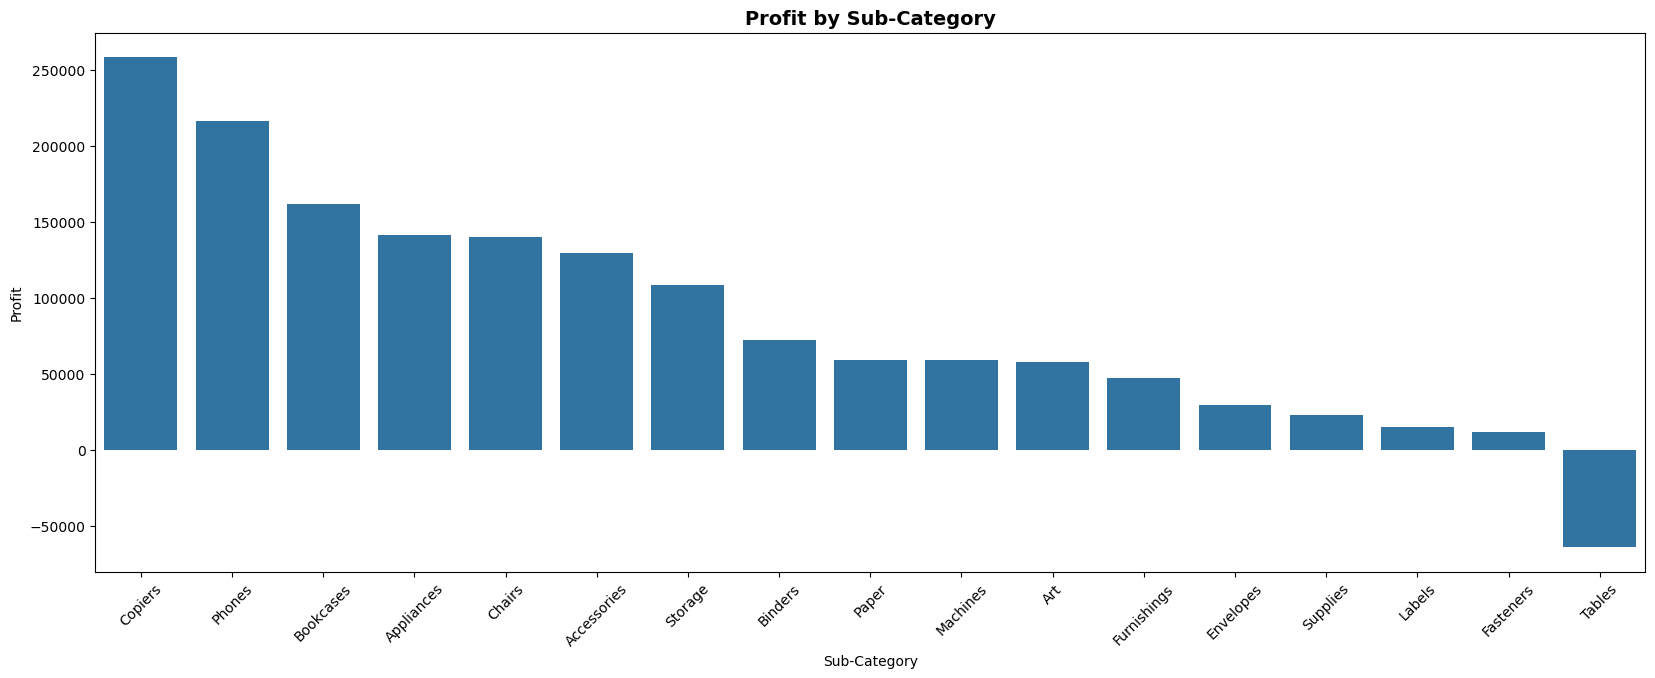

In [27]:
plt.figure(figsize=(20,7))
sns.barplot(x=subcategory_profit.index,y=subcategory_profit.values)
plt.title('Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.show()

**Top performers (Technology + some Furniture):
Copiers, Phones, Bookcases, Appliances — all above $140K profit**

**Middle performers:
Chairs, Accessories, Storage, Binders — $50K–$140K**

**Loss maker:
Tables → immediate business action required**

## Which products are the most profitable?

In [28]:
top_products = df.groupby('Product.Name')['Profit'].sum().sort_values(ascending=False)
top_products.head(10)

Product.Name
Canon imageCLASS 2200 Advanced Copier                       25199.9280
Cisco Smart Phone, Full Size                                17238.5206
Motorola Smart Phone, Full Size                             17027.1130
Hoover Stove, Red                                           11807.9690
Sauder Classic Bookcase, Traditional                        10672.0730
Harbour Creations Executive Leather Armchair, Adjustable    10427.3260
Nokia Smart Phone, Full Size                                 9938.1955
Cisco Smart Phone, with Caller ID                            9786.6408
Nokia Smart Phone, with Caller ID                            9465.3257
Belkin Router, USB                                           8955.0180
Name: Profit, dtype: float64

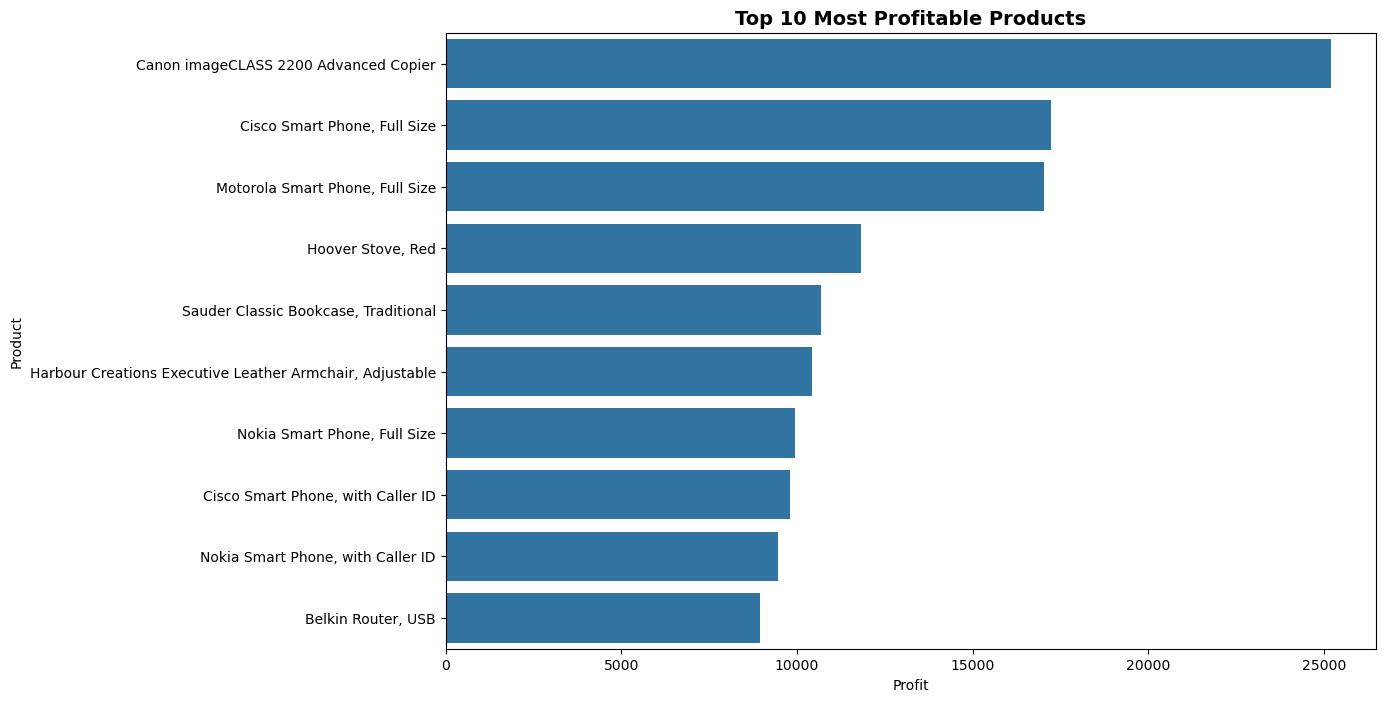

In [29]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_products.head(10).values,y=top_products.head(10).index)
plt.title('Top 10 Most Profitable Products', fontsize=14, fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('Product')
plt.show()

**1 — Canon Copier is the star product
At ~$25,000 profit it is 47% more profitable than second place — a single product generating this much profit is extraordinary.**

**2 — Smartphones dominate the top 10
Cisco, Motorola, Nokia appear multiple times — 6 out of 10 are phones or communication devices. This confirms why Phones was the 2nd most profitable sub-category.**

**3 — Interesting outlier — Hoover Stove
A kitchen appliance appearing at #4 among tech products is unexpected — suggests premium pricing and strong margins in appliances.**

## Which products consistently lose money?

In [30]:
top_products.tail(10)

Product.Name
Lesro Training Table, Rectangular                          -2581.2834
Bevis Wood Table, with Bottom Storage                      -2782.5880
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases   -2876.1156
Rogers Lockers, Blue                                       -2893.4908
Bevis Computer Table, Fully Assembled                      -3509.5638
Bevis Round Table, Adjustable Height                       -3649.8940
Cubify CubeX 3D Printer Triple Head Print                  -3839.9904
Motorola Smart Phone, Cordless                             -4447.0380
Lexmark MX611dhe Monochrome Laser Printer                  -4589.9730
Cubify CubeX 3D Printer Double Head Print                  -8879.9704
Name: Profit, dtype: float64

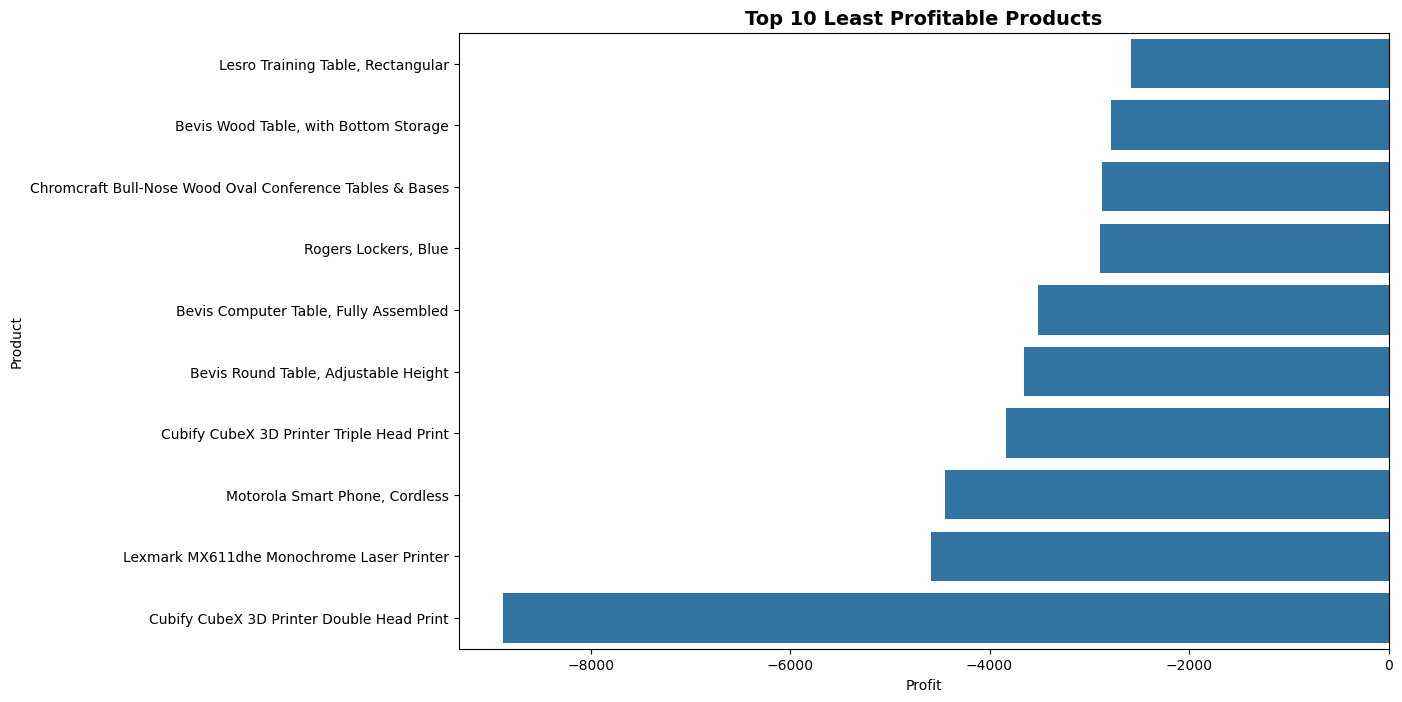

In [31]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_products.tail(10).values,y=top_products.tail(10).index)
plt.title('Top 10 Least Profitable Products', fontsize=14, fontweight='bold')
plt.xlabel('Profit')
plt.ylabel('Product')
plt.show()

**1 — Cubify 3D Printer is the biggest money loser
At -$8,900 it loses nearly double the second worst product. Both Cubify models appear in the top 10 — the entire 3D printer line is problematic.**

**2 — Tables dominate the loss list
Bevis Round Table, Bevis Computer Table, Bevis Wood Table, Chromcraft Conference Table, Lesro Training Table — 5 out of 10 are tables — confirming exactly what the sub-category chart showed.**

**3 — Interesting — Motorola Cordless Phone loses money
But Motorola Smart Phone Full Size was in the TOP 10 most profitable! Same brand, completely different profitability. The cordless phone is likely heavily discounted.**

## Which customer segments generate the highest profit?

In [32]:
profit_per_segment=df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
profit_per_segment

Segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: Profit, dtype: float64

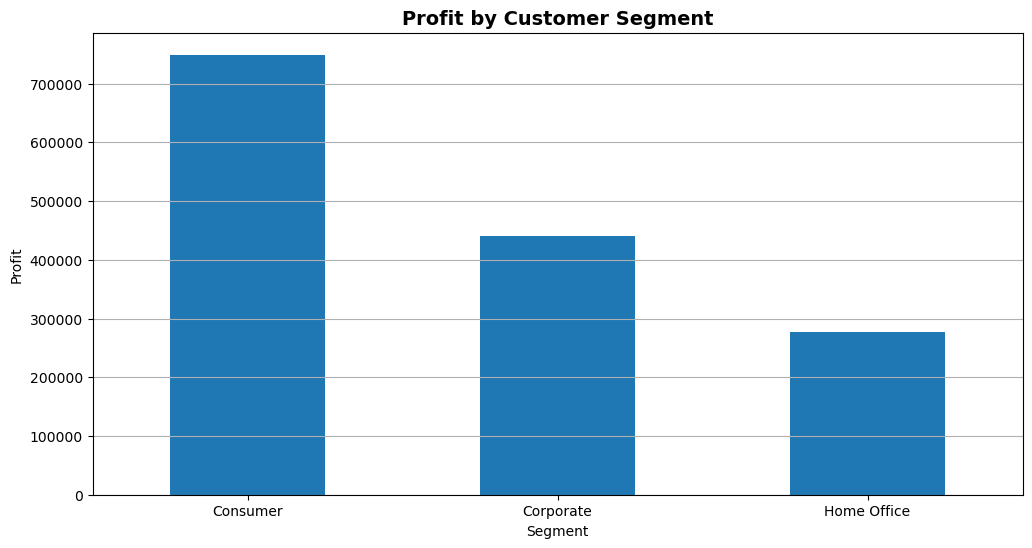

In [33]:
plt.figure(figsize=(12,6))
profit_per_segment.plot(kind='bar')
plt.title('Profit by Customer Segment', fontsize=14, fontweight='bold')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [34]:
# We do this in order to find which segment is actually more efficient 
sales_per_segment = df.groupby('Segment')['Sales'].sum()
profit_per_segment = df.groupby('Segment')['Profit'].sum()

margin = (profit_per_segment / sales_per_segment * 100).round(2)
print(margin)

Segment
Consumer       11.51
Corporate      11.54
Home Office    11.99
dtype: float64


## Profit Margin by Segment

**While Consumer generates the highest absolute profit (~$745K), 
this is purely a function of sales volume, not segment quality.**

When measured by profit margin, all three segments perform 
almost identically:
- Home Office: 11.99% (slightly most efficient)
- Corporate: 11.54%
- Consumer: 11.51%

## Who are the top 10 customers by sales?

In [35]:
top_customer_by_sales=df.groupby('Customer.Name')['Sales'].sum().sort_values(ascending=False)
top_customer_by_sales.head(10)

Customer.Name
Tom Ashbrook          40489
Tamara Chand          37453
Greg Tran             35552
Christopher Conant    35187
Sean Miller           35170
Bart Watters          32315
Natalie Fritzler      31778
Fred Hopkins          30404
Jane Waco             30288
Hunter Lopez          30246
Name: Sales, dtype: int64

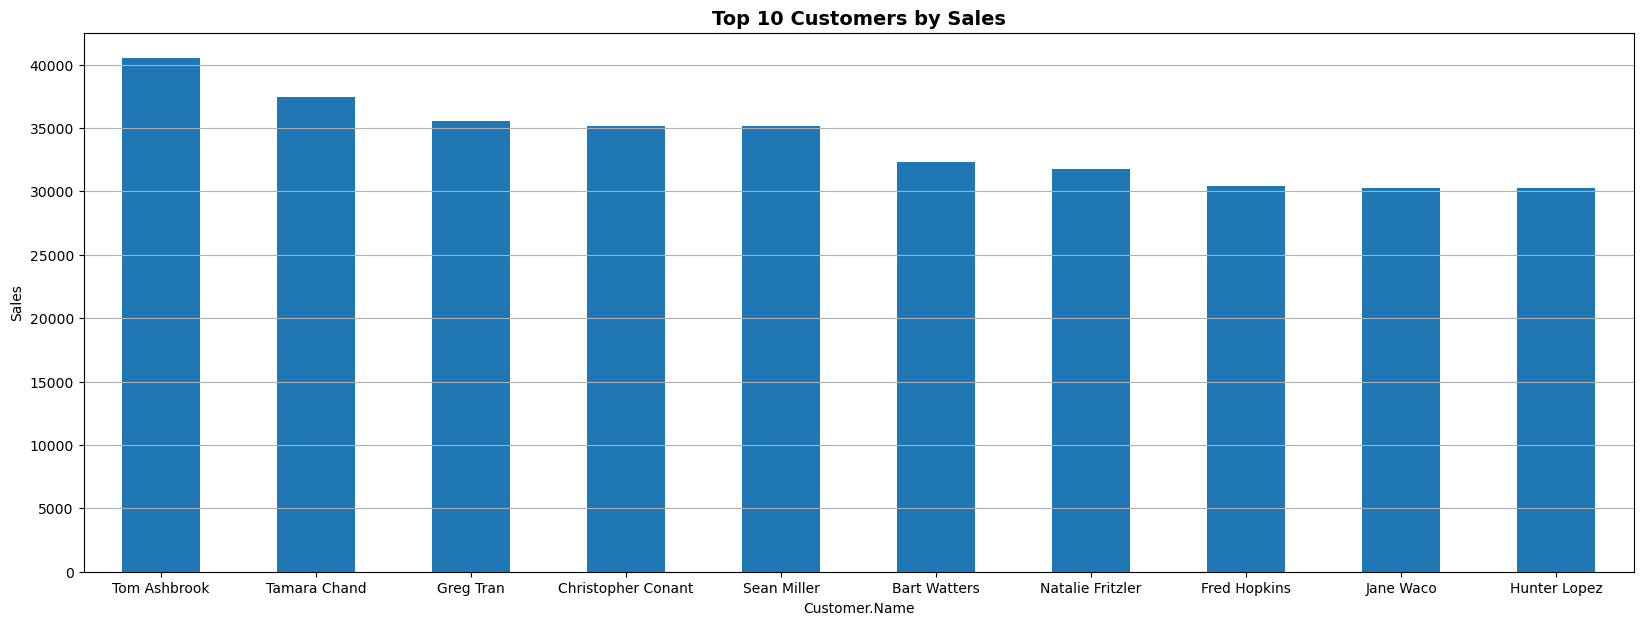

In [36]:
plt.figure(figsize=(20,7))
top_customer_by_sales.head(10).plot(kind='bar')
plt.title('Top 10 Customers by Sales', fontsize=14, fontweight='bold')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

**1 — Tom Ashbrook is the top customer
At ~$40,500 he leads the company's customer base, ~9% ahead of second place Tamara Chand.**

**2 — The top 10 are tightly clustered
From Tom Ashbrook (~$40,500) down to Hunter Lopez (~$30,000), the spread is relatively narrow — about 26% difference between #1 and #10. This suggests a stable group of high-value repeat customers rather than one dominant outlier.**

**3 — No single customer dominates disproportionately
Unlike charts where one entity vastly outpaces the rest, here all 10 customers contribute meaningfully and similarly to top-tier revenue.**

## Who are the least profitable customers?

In [37]:
customer_profit =df.groupby('Customer.Name')['Profit'].sum().sort_values(ascending=False)
least_prof_customers=customer_profit.tail(10)
least_prof_customers

Customer.Name
Julie Creighton   -1889.10592
Sean Braxton      -1896.97930
David Bremer      -2270.69658
Sharelle Roach    -2551.18846
Denise Monton     -2597.80290
Skye Norling      -2637.98050
Candace McMahon   -2798.79060
Grant Thornton    -3577.92306
Luke Foster       -3644.34750
Cindy Stewart     -6151.55810
Name: Profit, dtype: float64

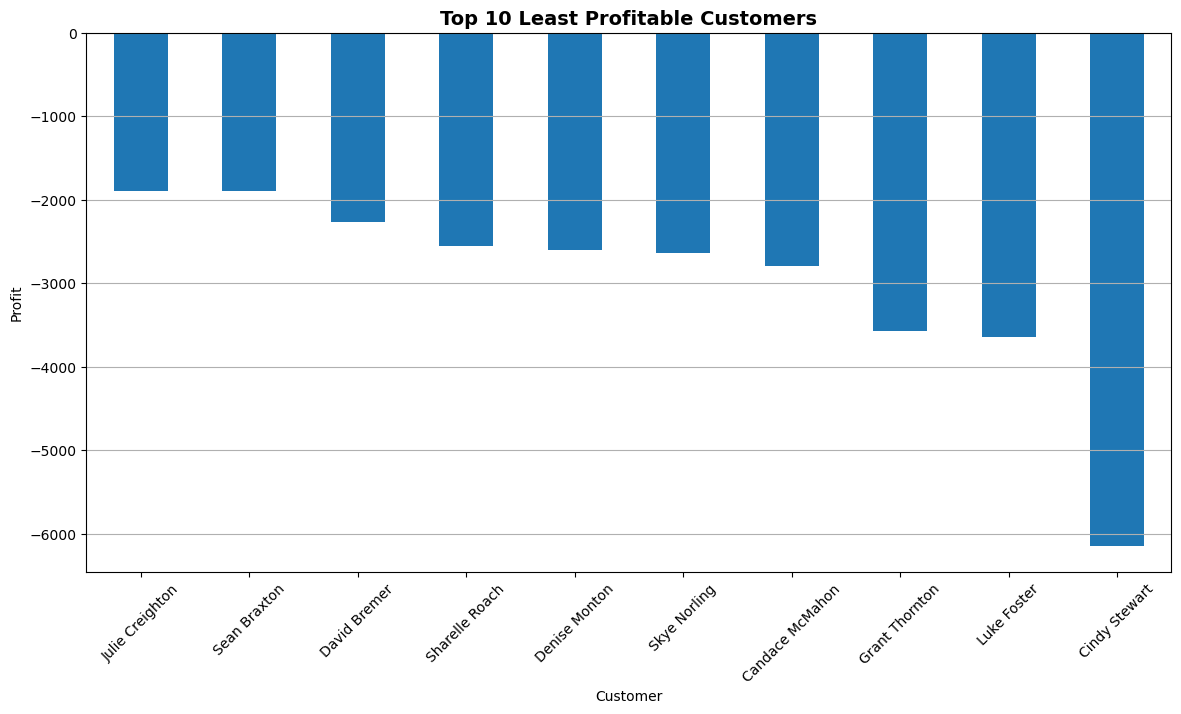

In [38]:
plt.figure(figsize=(14,7))
least_prof_customers.plot(kind='bar')
plt.title('Top 10 Least Profitable Customers', fontsize=14, fontweight='bold')
plt.ylabel('Profit')
plt.xlabel('Customer')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

**1 — Cindy Stewart is the most unprofitable customer by far
At -$6,152 she generates nearly double the loss of the second worst customer (Luke Foster/Grant Thornton at ~-$3,400). This single account is actively hurting profitability.**

**2 — All 10 customers are net negative
Unlike typical customer analysis where you look at top spenders, this entire list represents accounts where the company loses money on every transaction — likely due to heavy discounting or high return rates.**

**3 — A meaningful gap separates the top 3 from the rest
Cindy Stewart, Luke Foster and Grant Thornton form a distinct "high concern" tier with losses above $3,000, while the remaining 7 customers cluster between -$1,850 and -$2,650.**

## Which shipping mode performs best?

In [39]:
shipping_mode =df.groupby('Ship.Mode').agg(Total_Sales=('Sales','sum'),Total_Profit=('Profit','sum'),Avg_Shipping_Cost=('Shipping.Cost','mean')).sort_values('Total_Profit',ascending=False)
shipping_mode

,Total_Sales,Total_Profit,Avg_Shipping_Cost
Ship.Mode,,,
Standard Class,7578889,890596.02120,19.971654
Second Class,2565747,292583.52708,30.469666
First Class,1831067,208104.67520,41.052970
Same Day,667202,76173.06780,42.937325


<Figure size 1200x600 with 0 Axes>

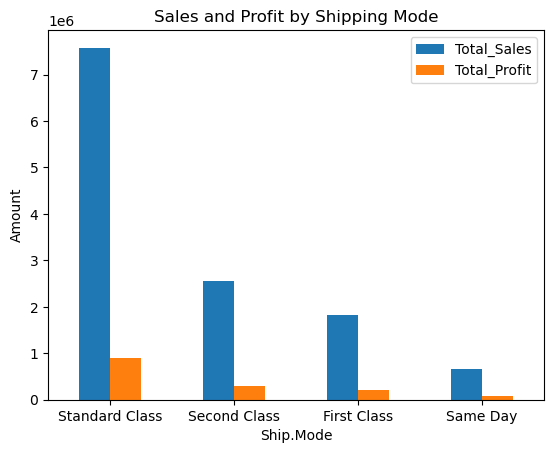

In [40]:
plt.figure(figsize=(12,6))
shipping_mode[['Total_Sales','Total_Profit']].plot(kind='bar',)
plt.title('Sales and Profit by Shipping Mode')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

**1. Standard Class dominates volume. It drives roughly 3x the sales of Second Class and nearly 4x First Class — this is clearly the default/most-used shipping option for customers.**

**2. Profit doesn't scale proportionally with sales. Standard Class has huge sales but its profit bar is disproportionately small relative to its sales bar compared to the other categories — suggesting a lower profit margin, possibly due to discounting or higher shipping/handling costs eating into margin.**

**3. Same Day shipping is a tiny slice of the business — both in sales and profit. Either it's underused (customers don't want/need it) or it's not being marketed/priced attractively.**

**4. First Class has decent sales but thin profit, similar pattern to Standard Class — worth checking if certain shipping modes are tied to heavier discounting.**

## Does shipping time affect profitability?

In [41]:
df[['Shipping_Days','Profit']].corr()

,Shipping_Days,Profit
Shipping_Days,1.000000,0.001745
Profit,0.001745,1.000000


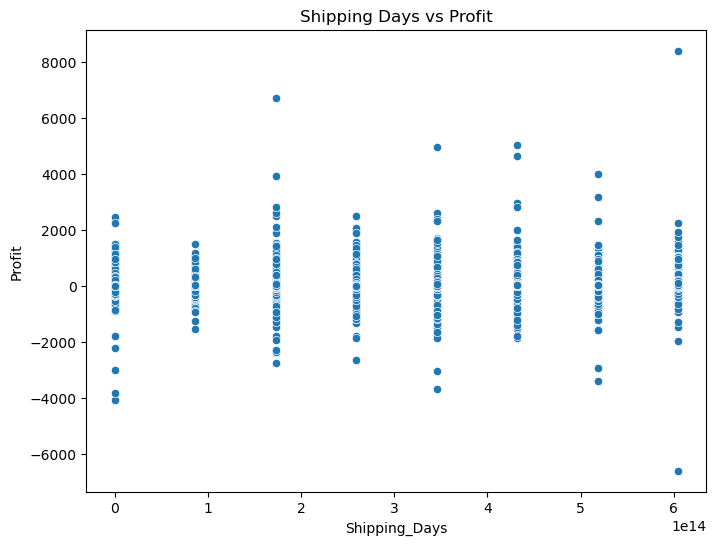

In [42]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Shipping_Days'],y=df['Profit'])
plt.title('Shipping Days vs Profit')
plt.show()

**Correlation ~0 tells us shipping speed and profit are (currently) unrelated — profit doesn't get better or worse based on how long shipping takes. Once you fix the day calculation, re-check this — it might change, though probably not by much since it's a scale issue, not an ordering issue (relative differences may still roughly hold).**

**Profit variance is high across all shipping durations — you see values from -$4,000 to +$8,000 no matter which "day group" you look at. This tells you profit is driven by something else entirely (product category, discount, order size) — not delivery speed.**

**Negative profit orders exist across every shipping tier — meaning loss-making orders aren't concentrated in slow or fast shipping; the losses are systemic elsewhere.**

## Which order priority generates the highest profit?

In [43]:
priority_profit =df.groupby('Order.Priority')['Profit'].sum().sort_values(ascending=False)
priority_profit

Order.Priority
Medium      864203.76262
High        420373.51340
Critical    124224.16428
Low          58655.85098
Name: Profit, dtype: float64

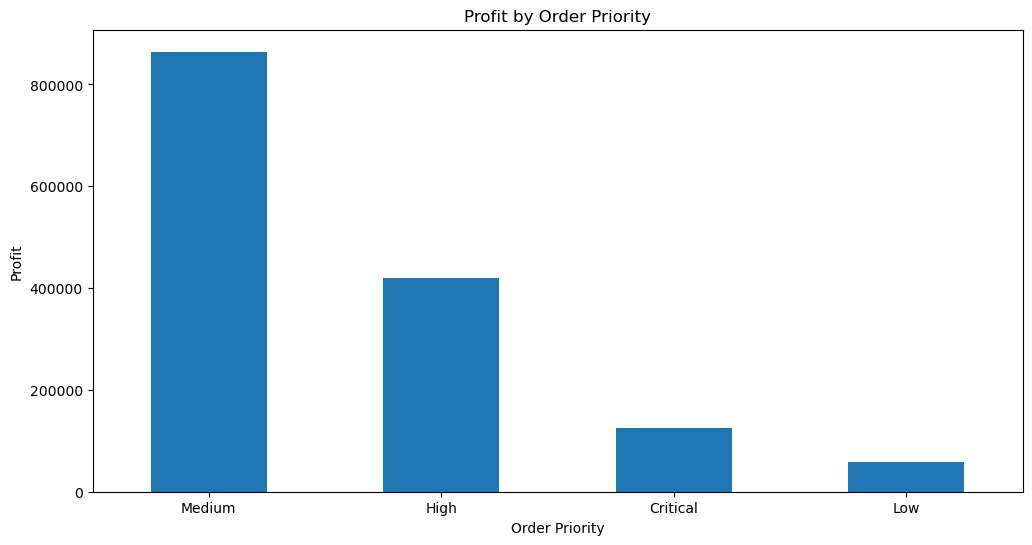

In [44]:
plt.figure(figsize=(12,6))
priority_profit.plot(kind='bar')
plt.title('Profit by Order Priority')
plt.xlabel('Order Priority')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

**Medium priority orders generate by far the most profit (~$870K) — more than double High priority, and about 7x Critical.**

**Critical and Low priority orders contribute very little profit — combined they're still less than 20% of what Medium alone generates.**

**This is likely a volume effect, not a margin effect. Most orders probably get tagged "Medium" priority by default (it's usually the standard/default option in order systems), so it naturally has the highest total profit simply because it has the most orders — not necessarily because it's more profitable per order.**

**"Critical" priority orders being low-profit is a flag worth investigating — are these rush/urgent orders being handled at a discount, or fulfilled at a cost that eats into margin? Businesses often absorb costs to satisfy urgent customers, which can quietly bleed profit.**

# Executive Summary

This project analyzes the Global Superstore dataset to evaluate the company's sales performance, profitability, customer behavior, product performance, and shipping operations across multiple international markets.

The objective was to identify the key drivers of revenue and profit while uncovering operational inefficiencies and business opportunities through exploratory data analysis. A comprehensive business-oriented approach was applied, including data cleaning, feature engineering, descriptive analytics, and visualization.

The analysis explored twenty business questions covering geographical performance, customer segments, product profitability, shipping efficiency, and operational priorities.

The findings reveal that sales and profitability are concentrated in a limited number of countries, markets, and customer segments. Several products consistently generate losses despite continued sales, while specific shipping methods and order priorities contribute significantly more profit than others.

Overall, the analysis provides actionable insights that can support strategic decision-making regarding market expansion, product portfolio optimization, logistics management, and customer relationship strategies.

# Conclusions

- Sales are concentrated in a relatively small number of countries, indicating that a few key markets drive a substantial portion of the company's revenue.
- Profitability varies considerably across markets and regions, demonstrating that high sales do not always translate into high profits.
- Certain product categories and sub-categories consistently outperform others, highlighting the importance of product portfolio optimization.
- Several individual products generate persistent financial losses and should be reviewed for pricing, supplier costs, or potential discontinuation.
- Customer purchasing behavior differs significantly across segments, suggesting opportunities for targeted marketing and personalized sales strategies.
- A relatively small group of customers contributes a disproportionately large share of total sales, emphasizing the importance of customer retention initiatives.
- Standard Class shipping dominates both sales volume and total profit, making it the company's most operationally important shipping method.
- Shipping duration shows little or no relationship with profitability, indicating that reducing delivery time alone is unlikely to increase profits.
- Order priority influences profitability, with medium-priority orders contributing the highest total profit.
- Overall, business performance depends on a combination of market selection, customer behavior, pricing strategy, product mix, and operational efficiency rather than on a single factor.

# Recommendations

- Increase investment in the highest-performing countries and markets while monitoring opportunities for expansion.
- Investigate underperforming regions to identify operational inefficiencies, pricing issues, or market-specific challenges.
- Prioritize high-margin product categories through inventory planning and marketing campaigns.
- Review consistently unprofitable products and evaluate pricing adjustments, supplier negotiations, or discontinuation.
- Develop customer loyalty programs targeting the company's highest-value customers.
- Optimize shipping operations by maintaining the efficiency of Standard Class while evaluating the cost-effectiveness of premium shipping options.
- Continue monitoring regional profitability rather than focusing exclusively on sales growth.
- Use data-driven decision making when allocating marketing budgets across countries, customer segments, and product categories.
- Build executive dashboards that continuously monitor sales, profit, customer performance, and operational KPIs.
- Expand future analyses by incorporating forecasting models and predictive analytics to support long-term business planning.